In [3]:
# insert code here
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input
from tensorflow import keras

from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

In [4]:
import os

# pick a number you want (use your real physical core count if you know it)
os.environ["LOKY_MAX_CPU_COUNT"] = "16"


In [5]:
# --- COMPLETE CELL: Yahoo Finance (yfinance) + FRED (fredapi) ---
# pip install yfinance fredapi scikit-learn pandas numpy matplotlib

import os
import numpy as np
import pandas as pd
import yfinance as yf

from fredapi import Fred

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# =========================
# 0) CONFIG
# =========================
START = "2005-01-01"
END = "2026-09-30"  # Frozen: data through 2026-09-29 (yfinance end date is exclusive). Set to None for latest data.
FRED_API_KEY = os.getenv("FRED_API_KEY") or "PASTE_YOUR_FRED_KEY_HERE"  # <-- set env var or paste

# Yahoo tickers (your list)
TICKERS = {
    "SPY": "SPY",
    "DXY": "DX-Y.NYB",     # (your dxy-y.nyb)
    "VIX": "^VIX",
    "VIX9D": "^VIX9D",     # (your vix9d)
    "IXIC": "^IXIC",
    "DJI": "^DJI",
    "ES": "ES=F",
    "TNX": "^TNX",         # (your 6tnx -> ^TNX)
    "GC": "GC=F",
    "CL": "CL=F",
    "NQ": "NQ=F",
    "FVX": "^FVX",
    "IRX": "^IRX"
}

# FRED series (macro)
FRED_SERIES = {
    "GDP": "GDPC1",        # Real GDP (quarterly)
    "CPI": "CPIAUCSL"      # CPI-U (monthly)
}

# =========================
# 1) DOWNLOAD MARKET DATA (YAHOO)
# =========================
raw = yf.download(
    tickers=list(TICKERS.values()),
    start=START,
    end=END,
    group_by="ticker",
    auto_adjust=False,
    threads=True,
    progress=False
)

def pull_price(df, sym):
    """Prefer Adj Close; fallback to Close. Works with MultiIndex download."""
    if isinstance(df.columns, pd.MultiIndex):
        cols = df[sym].columns
        field = "Adj Close" if "Adj Close" in cols else "Close"
        return df[(sym, field)]
    else:
        field = "Adj Close" if "Adj Close" in df.columns else "Close"
        return df[field]

market = []
for name, sym in TICKERS.items():
    try:
        s = pull_price(raw, sym).rename(name)
        market.append(s)
    except Exception as e:
        print(f"[WARN] Could not load {name} ({sym}): {e}")

df_mkt = pd.concat(market, axis=1).sort_index()

# Drop columns that are entirely NaN (symbol failed)
all_nan_cols = df_mkt.columns[df_mkt.isna().all()].tolist()
if all_nan_cols:
    print("[INFO] Dropping all-NaN Yahoo columns:", all_nan_cols)
    df_mkt = df_mkt.drop(columns=all_nan_cols)


# =========================
# 2) DOWNLOAD MACRO DATA (FRED)
# =========================
import pandas_datareader.data as web
import datetime as dt

start = dt.datetime(2005,1,1)
end = dt.datetime(2026,9,29)  # Frozen to match market data. Use dt.datetime.today() for latest.

gdp = web.DataReader("GDPC1", "fred", start, end)
cpi = web.DataReader("CPIAUCSL", "fred", start, end)

df_macro = pd.concat([gdp, cpi], axis=1)
df_macro.columns = ["GDP","CPI"]
df_macro = df_macro.sort_index()

# Reindex to daily calendar and forward-fill
df_macro_daily = df_macro.reindex(df_mkt.index).ffill()

# =========================
# 3) MERGE
# =========================
df = df_mkt.join(df_macro_daily, how="left")

# =========================
# 4) FEATURE ENGINEERING
# =========================
def add_features(d):
    out = d.copy()

    # returns (1/5/10)
    base_cols = ["SPY","IXIC","DJI","ES","NQ","DXY","VIX","VIX9D","GC","CL"]
    for c in base_cols:
        if c in out.columns:
            out[f"{c}_ret1"]  = out[c].pct_change(fill_method=None)
            out[f"{c}_ret5"]  = out[c].pct_change(5, fill_method=None)
            out[f"{c}_ret10"] = out[c].pct_change(10, fill_method=None)

    # vol/momentum (SPY)
    if "SPY_ret1" in out.columns:
        out["SPY_vol10"] = out["SPY_ret1"].rolling(10).std()
        out["SPY_vol20"] = out["SPY_ret1"].rolling(20).std()
        out["SPY_mom20"]  = out["SPY"].pct_change(20, fill_method=None)

    # yields: changes + spread-ish
    for y in ["TNX", "FVX", "IRX"]:
        if y in out.columns:
            out[f"{y}_chg1"] = out[y].diff()
            out[f"{y}_chg5"] = out[y].diff(5)

    if {"TNX","IRX"}.issubset(out.columns):
        out["TNX_minus_IRX"] = out["TNX"] - out["IRX"]

    # VIX term (9D - 30D)
    if {"VIX","VIX9D"}.issubset(out.columns):
        out["VIX9D_minus_VIX"] = out["VIX9D"] - out["VIX"]

    # Macro transforms
    if "CPI" in out.columns:
        out["CPI_yoy"] = out["CPI"].pct_change(12)          # monthly yoy (since CPI is monthly)
        out["CPI_mom"] = out["CPI"].pct_change(1)
    if "GDP" in out.columns:
        out["GDP_yoy"] = out["GDP"].pct_change(4)           # quarterly yoy
        out["GDP_qoq"] = out["GDP"].pct_change(1)

    # Optional: simple regime flags
    if "CPI_yoy" in out.columns:
        out["infl_high"] = (out["CPI_yoy"] > out["CPI_yoy"].rolling(60).median()).astype(float)
    if "GDP_yoy" in out.columns:
        out["growth_high"] = (out["GDP_yoy"] > out["GDP_yoy"].rolling(60).median()).astype(float)

    return out

df_feat = add_features(df)


# =========================
# 5) LABEL (NEXT-DAY SPY UP/DOWN)
# =========================
df_feat["y_up_next1d"] = (df_feat["SPY"].shift(-1) > df_feat["SPY"]).astype(int)

# Build X/y WITHOUT nuking the dataset
y = df_feat["y_up_next1d"].dropna().astype(int)
X = df_feat.drop(columns=["y_up_next1d"]).loc[y.index]

# Keep rows with enough non-NaNs (imputer handles the rest)
min_non_nan = max(50, int(0.5 * X.shape[1]))
mask = (X.notna().sum(axis=1) >= min_non_nan)
X, y = X.loc[mask], y.loc[mask]

print("Final samples:", len(X), "| features:", X.shape[1])

# =========================
# 6) MODELS + TIME-SERIES CV
# =========================
pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

pipe_hgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("model", HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05))
])

def align_drop_all_nan(Xtr, Xte):
    # Drop columns that are all-NaN in TRAIN (imputer can't learn anything)
    all_nan = Xtr.columns[Xtr.isna().all()].tolist()
    if all_nan:
        Xtr = Xtr.drop(columns=all_nan)
        Xte = Xte.drop(columns=all_nan, errors="ignore")

    # Also ensure Xte has exactly the same columns/order as Xtr
    Xte = Xte.reindex(columns=Xtr.columns)
    return Xtr, Xte, all_nan


def ts_cv_scores(model, X, y, n_splits=6, verbose=False):
    n = len(X)
    n_splits = min(n_splits, max(2, n // 250))
    tscv = TimeSeriesSplit(n_splits=n_splits)

    accs, aucs = [], []
    dropped_seen = set()

    for i, (tr, te) in enumerate(tscv.split(X), 1):
        Xtr, Xte = X.iloc[tr].copy(), X.iloc[te].copy()
        ytr, yte = y.iloc[tr], y.iloc[te]

        Xtr, Xte, dropped = align_drop_all_nan(Xtr, Xte)
        if verbose and dropped:
            new = [c for c in dropped if c not in dropped_seen]
            if new:
                print(f"Fold {i}: dropped all-NaN train cols: {new}")
                dropped_seen.update(new)

        model.fit(Xtr, ytr)

        p = model.predict_proba(Xte)[:, 1]
        yhat = (p >= 0.5).astype(int)

        accs.append(accuracy_score(yte, yhat))
        if len(np.unique(yte)) == 2:
            aucs.append(roc_auc_score(yte, p))

    return float(np.mean(accs)), (float(np.mean(aucs)) if aucs else np.nan), n_splits

lr_acc, lr_auc, k1 = ts_cv_scores(pipe_lr, X, y)
hgb_acc, hgb_auc, k2 = ts_cv_scores(pipe_hgb, X, y)

print(f"\nTimeSeries CV folds used: LR={k1}, HGB={k2}")
print(f"LogReg | Acc: {lr_acc:.3f} | AUC: {lr_auc:.3f}")
print(f"HGB    | Acc: {hgb_acc:.3f} | AUC: {hgb_auc:.3f}")

# =========================
# 7) OOS BACKTEST (LAST 20%) + LATEST PREDICTION
# =========================
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

X_train2, X_test2, dropped = align_drop_all_nan(X_train.copy(), X_test.copy())
if dropped:
    print("OOS split: dropped all-NaN train cols:", dropped)

pipe_hgb.fit(X_train2, y_train)
p_test = pipe_hgb.predict_proba(X_test2)[:, 1]
yhat_test = (p_test >= 0.5).astype(int)

print("\nOOS (last 20%) - HGB")
print("Accuracy:", round(accuracy_score(y_test, yhat_test), 3))
if len(np.unique(y_test)) == 2:
    print("AUC:", round(roc_auc_score(y_test, p_test), 3))
print("Confusion matrix:\n", confusion_matrix(y_test, yhat_test))
print("\nClassification report:\n", classification_report(y_test, yhat_test))

# Fit on all data and predict next day probability
X_all_tr, X_last, dropped = align_drop_all_nan(X.copy(), X.tail(1).copy())
pipe_hgb.fit(X_all_tr, y)
p_next = pipe_hgb.predict_proba(X_last)[:, 1][0]
pred = int(p_next >= 0.5)
print(f"\nLatest feature date: {X.index[-1].date()}")
print(f"Predicted P(SPY up next day) = {p_next:.3f}  =>  y_up_next1d = {pred}")


Final samples: 5405 | features: 62

TimeSeries CV folds used: LR=6, HGB=6
LogReg | Acc: 0.497 | AUC: 0.506
HGB    | Acc: 0.525 | AUC: 0.494

OOS (last 20%) - HGB
Accuracy: 0.51
AUC: 0.502
Confusion matrix:
 [[204 294]
 [236 347]]

Classification report:
               precision    recall  f1-score   support

           0       0.46      0.41      0.43       498
           1       0.54      0.60      0.57       583

    accuracy                           0.51      1081
   macro avg       0.50      0.50      0.50      1081
weighted avg       0.51      0.51      0.51      1081


Latest feature date: 2026-09-29
Predicted P(SPY up next day) = 0.369  =>  y_up_next1d = 0


In [6]:
print("VIX9D non-null:", df["VIX9D"].notna().sum())
print(df[["VIX9D", "VIX"]].tail(15))


VIX9D non-null: 3958
                VIX9D        VIX
Date                            
2026-09-09  15.590000  16.459999
2026-09-10  17.700001  17.840000
2026-09-11  14.470000  15.840000
2026-09-14  16.910000  17.100000
2026-09-15  17.209999  17.200001
2026-09-16  17.400000  17.709999
2026-09-17  13.390000  15.440000
2026-09-18  12.270000  14.810000
2026-09-21  13.140000  14.870000
2026-09-22  12.130000  14.210000
2026-09-23  13.450000  15.180000
2026-09-24  14.110000  15.670000
2026-09-25  12.760000  14.870000
2026-09-28  14.390000  16.070000
2026-09-29  14.080000  16.010000


Samples: 5469
5-Day CV Accuracy: 0.507
5-Day CV AUC: 0.508


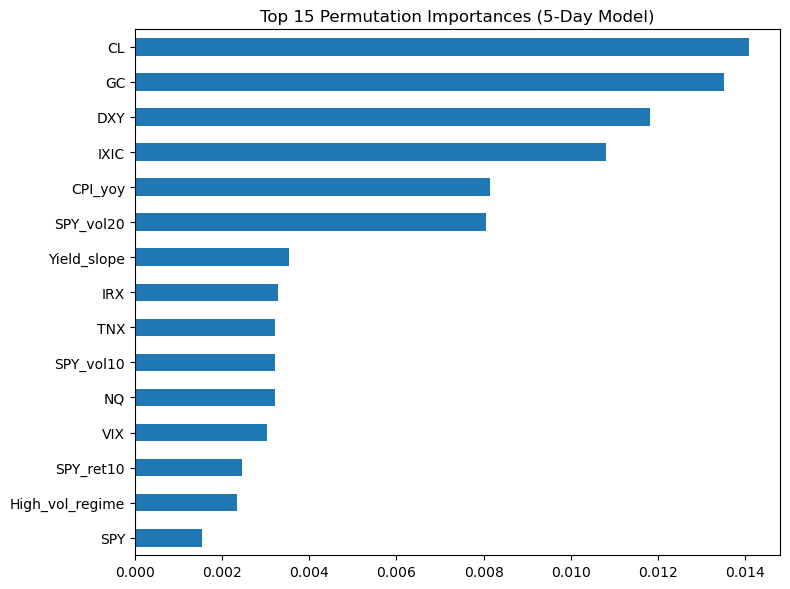

Latest P(SPY up next 5 days) = 0.238


In [7]:
# =========================
# 5-DAY PREDICTION + REGIME + FEATURE IMPORTANCE
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score

# =========================
# 1) FEATURE ENGINEERING
# =========================

df_feat = df.copy()

# Returns
df_feat["SPY_ret1"]  = df_feat["SPY"].pct_change(fill_method=None)
df_feat["SPY_ret5"]  = df_feat["SPY"].pct_change(5, fill_method=None)
df_feat["SPY_ret10"] = df_feat["SPY"].pct_change(10, fill_method=None)

# Volatility
df_feat["SPY_vol10"] = df_feat["SPY_ret1"].rolling(10).std()
df_feat["SPY_vol20"] = df_feat["SPY_ret1"].rolling(20).std()

# Drawdown
df_feat["SPY_dd20"] = df_feat["SPY"] / df_feat["SPY"].rolling(20).max() - 1

# Yield curve
if {"TNX","IRX"}.issubset(df_feat.columns):
    df_feat["Yield_slope"] = df_feat["TNX"] - df_feat["IRX"]

# VIX term structure
if {"VIX","VIX9D"}.issubset(df_feat.columns):
    df_feat["VIX_term"] = df_feat["VIX9D"] - df_feat["VIX"]

# Macro growth/inflation features
if "CPI" in df_feat.columns:
    df_feat["CPI_yoy"] = df_feat["CPI"].pct_change(12, fill_method=None)

if "GDP" in df_feat.columns:
    df_feat["GDP_yoy"] = df_feat["GDP"].pct_change(4, fill_method=None)

# =========================
# 2) REGIME CLASSIFICATION
# =========================

# Inflation regime (high vs low)
if "CPI_yoy" in df_feat.columns:
    median_infl = df_feat["CPI_yoy"].rolling(60).median()
    df_feat["Inflation_high"] = (df_feat["CPI_yoy"] > median_infl).astype(int)

# Growth regime
if "GDP_yoy" in df_feat.columns:
    median_growth = df_feat["GDP_yoy"].rolling(60).median()
    df_feat["Growth_high"] = (df_feat["GDP_yoy"] > median_growth).astype(int)

# Volatility regime
df_feat["High_vol_regime"] = (df_feat["SPY_vol20"] > df_feat["SPY_vol20"].rolling(60).median()).astype(int)

# =========================
# 3) 5-DAY LABEL
# =========================

df_feat["y_up_next5d"] = (df_feat["SPY"].shift(-5) > df_feat["SPY"]).astype(int)

y = df_feat["y_up_next5d"].dropna().astype(int)
X = df_feat.drop(columns=["y_up_next5d"]).loc[y.index]

# Drop rows with insufficient data
mask = X.notna().sum(axis=1) >= int(0.5 * X.shape[1])
X, y = X.loc[mask], y.loc[mask]

print("Samples:", len(X))

# =========================
# 4) MODEL
# =========================

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05))
])

# TimeSeries CV
tscv = TimeSeriesSplit(n_splits=6)

accs, aucs = [], []

for tr, te in tscv.split(X):
    Xtr, Xte = X.iloc[tr].copy(), X.iloc[te].copy()
    Xtr, Xte, dropped = align_drop_all_nan(Xtr, Xte)
    ytr, yte = y.iloc[tr], y.iloc[te]
    pipe.fit(Xtr, ytr)

    p = pipe.predict_proba(Xte)[:,1]
    yhat = (p >= 0.5).astype(int)

    accs.append(accuracy_score(yte, yhat))
    if len(np.unique(yte)) == 2:
        aucs.append(roc_auc_score(yte, p))

print("5-Day CV Accuracy:", round(np.mean(accs),3))
print("5-Day CV AUC:", round(np.mean(aucs),3))

# =========================
# 5) FEATURE IMPORTANCE
# =========================

# Fit full model
pipe.fit(X, y)

result = permutation_importance(
    pipe, X, y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(result.importances_mean, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
importances.sort_values().plot(kind="barh")
plt.title("Top 15 Permutation Importances (5-Day Model)")
plt.tight_layout()
plt.show()

# =========================
# 6) LATEST PREDICTION
# =========================

p_next = pipe.predict_proba(X.tail(1))[:,1][0]
print("Latest P(SPY up next 5 days) =", round(p_next,3))


In [8]:
y.mean()

np.float64(0.5957213384530993)

In [9]:
# ============================================================
# REGRESSION + IC (Information Coefficient) ANALYSIS
# Predict SPY 5-day forward return using Yahoo + FRED features
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# Helpers
# -----------------------------
def spearman_ic(a, b):
    """Spearman rank correlation without scipy (rank + Pearson corr)."""
    a = pd.Series(a).rank(pct=True)
    b = pd.Series(b).rank(pct=True)
    return float(a.corr(b))

def add_features_for_regression(df):
    """
    Assumes df already has Yahoo columns (SPY, VIX, etc.) and FRED columns (GDP, CPI),
    indexed by date, with GDP/CPI forward-filled to daily.
    """
    out = df.copy()

    # Daily returns
    base_cols = ["SPY","IXIC","DJI","ES","NQ","DXY","VIX","VIX9D","GC","CL","TNX","FVX","IRX"]
    for c in base_cols:
        if c in out.columns:
            out[f"{c}_ret1"]  = out[c].pct_change(1, fill_method=None)
            out[f"{c}_ret5"]  = out[c].pct_change(5, fill_method=None)
            out[f"{c}_ret10"] = out[c].pct_change(10, fill_method=None)

    # SPY realized vol / drawdown / momentum
    if "SPY_ret1" in out.columns:
        out["SPY_vol10"] = out["SPY_ret1"].rolling(10).std()
        out["SPY_vol20"] = out["SPY_ret1"].rolling(20).std()
        out["SPY_mom20"] = out["SPY"].pct_change(20, fill_method=None)
        out["SPY_dd20"]  = out["SPY"] / out["SPY"].rolling(20).max() - 1

    # Term structure / spreads
    if {"VIX","VIX9D"}.issubset(out.columns):
        out["VIX_term"] = out["VIX9D"] - out["VIX"]
    if {"TNX","IRX"}.issubset(out.columns):
        out["Yield_slope_10y_3m"] = out["TNX"] - out["IRX"]
    if {"FVX","IRX"}.issubset(out.columns):
        out["Yield_slope_5y_3m"] = out["FVX"] - out["IRX"]

    # Macro transforms (GDP quarterly, CPI monthly)
    if "CPI" in out.columns:
        out["CPI_yoy"] = out["CPI"].pct_change(12, fill_method=None)   # monthly YoY
        out["CPI_mom"] = out["CPI"].pct_change(1, fill_method=None)
    if "GDP" in out.columns:
        out["GDP_yoy"] = out["GDP"].pct_change(4, fill_method=None)    # quarterly YoY
        out["GDP_qoq"] = out["GDP"].pct_change(1, fill_method=None)

    # Simple regimes (binary flags)
    if "SPY_vol20" in out.columns:
        out["regime_high_vol"] = (out["SPY_vol20"] > out["SPY_vol20"].rolling(60).median()).astype(float)
    if "CPI_yoy" in out.columns:
        out["regime_high_infl"] = (out["CPI_yoy"] > out["CPI_yoy"].rolling(60).median()).astype(float)
    if "GDP_yoy" in out.columns:
        out["regime_high_growth"] = (out["GDP_yoy"] > out["GDP_yoy"].rolling(60).median()).astype(float)

    return out

def backtest_long_short_from_scores(dates, y_true, y_pred, horizon=5, q=0.2, tc_bps=5):
    """
    Simple long/short: long top q, short bottom q based on predictions.
    Returns:
      - daily-ish series aligned to 'dates' (these are decision dates)
      - realized forward 5d return (label)
      - strategy forward 5d return with simple transaction cost proxy
    Notes:
      - This is a *toy* backtest: assumes you can enter at decision date close and realize exactly horizon return.
      - For SPY-only, long/short means long SPY or short SPY.
    """
    s = pd.DataFrame({"y": y_true, "p": y_pred}, index=pd.DatetimeIndex(dates)).dropna()
    if s.empty:
        return pd.DataFrame()

    # Determine long/short signals by quantiles of prediction
    p = s["p"]
    lo = p.quantile(q)
    hi = p.quantile(1 - q)

    sig = pd.Series(0.0, index=s.index)
    sig[p >= hi] = 1.0
    sig[p <= lo] = -1.0

    # transaction cost: charge when signal changes (entry/flip). tc_bps per side.
    # Convert bps to return
    tc = tc_bps / 10000.0
    turnover = sig.diff().abs().fillna(sig.abs())  # first position counts as entry
    cost = turnover * tc

    strat = sig * s["y"] - cost

    out = pd.DataFrame({
        "y_fwd": s["y"],
        "pred": s["p"],
        "signal": sig,
        "cost": cost,
        "strat_fwd": strat
    }, index=s.index)
    return out

# -----------------------------
# MAIN (expects df exists)
# -----------------------------
# You said you've already built df = Yahoo market + (CPI,GDP from FRED) merged and ffilled.
# df must include SPY; ideally includes CPI and GDP columns.
assert "df" in globals(), "You need a dataframe named df (Yahoo + FRED merged) before running this cell."
assert "SPY" in df.columns, "df must contain SPY."

df_feat = add_features_for_regression(df)

# 5-day forward return label (regression target)
df_feat["y_ret_next5d"] = df_feat["SPY"].shift(-5) / df_feat["SPY"] - 1.0

# Build X/y (keep label rows, don't nuke rows with a global dropna)
y = df_feat["y_ret_next5d"].dropna()
X = df_feat.drop(columns=["y_ret_next5d"]).loc[y.index]

# Keep rows with enough observed features; imputer handles remaining NaNs
min_non_nan = max(30, int(0.5 * X.shape[1]))
mask = X.notna().sum(axis=1) >= min_non_nan
X, y = X.loc[mask], y.loc[mask]

print(f"Samples: {len(X)} | Features: {X.shape[1]} | Date range: {X.index.min().date()} -> {X.index.max().date()}")

# -----------------------------
# Models
# -----------------------------
models = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ]),
    "HGBR": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            max_depth=3,
            learning_rate=0.05,
            max_iter=400,
            random_state=42
        ))
    ])
}

# -----------------------------
# TimeSeries CV evaluation + OOS predictions
# -----------------------------
tscv = TimeSeriesSplit(n_splits=6)

rows = []
oos_preds = {name: pd.Series(index=X.index, dtype=float) for name in models.keys()}

for fold, (tr, te) in enumerate(tscv.split(X), 1):
    Xtr, Xte = X.iloc[tr].copy(), X.iloc[te].copy()
    ytr, yte = y.iloc[tr], y.iloc[te]

    # Fold-robust: drop columns with ZERO observed values in training fold
    good_cols = Xtr.columns[Xtr.notna().sum() > 0]
    Xtr = Xtr[good_cols]
    Xte = Xte[good_cols]


    for name, pipe in models.items():
        pipe.fit(Xtr, ytr)
        p = pd.Series(pipe.predict(Xte), index=Xte.index)

        # Store OOS preds aligned by date
        oos_preds[name].loc[Xte.index] = p

        rmse = np.sqrt(mean_squared_error(yte, p))
        mae = mean_absolute_error(yte, p)
        r2 = r2_score(yte, p)
        ic = spearman_ic(yte, p)

        # directional "hit rate" based on sign (how often predicted sign matches realized sign)
        hit = float((np.sign(p) == np.sign(yte)).mean())

        rows.append({
            "fold": fold, "model": name,
            "rmse": rmse, "mae": mae, "r2": r2, "spearman_ic": ic, "hit_rate": hit,
            "n_test": len(yte)
        })

cv = pd.DataFrame(rows)
summary = cv.groupby("model")[["rmse","mae","r2","spearman_ic","hit_rate"]].mean().sort_values("spearman_ic", ascending=False)

print("\n=== TimeSeries CV (mean over folds) ===")
print(summary.round(4))

# -----------------------------
# OOS full-period metrics (using stitched OOS preds)
# -----------------------------
print("\n=== Stitched OOS metrics (all folds combined) ===")
for name, p in oos_preds.items():
    valid = p.dropna()
    yy = y.loc[valid.index]
    rmse = np.sqrt(mean_squared_error(yy, valid))
    mae = mean_absolute_error(yy, valid)
    r2 = r2_score(yy, valid)
    ic = spearman_ic(yy, valid)
    hit = float((np.sign(valid) == np.sign(yy)).mean())
    print(f"{name:5s} | RMSE {rmse:.4f} | MAE {mae:.4f} | R2 {r2:.4f} | Spearman IC {ic:.4f} | Hit {hit:.3f}")

# -----------------------------
# Decile spread / monotonicity check (on stitched OOS)
# -----------------------------
def decile_spread(y_true, y_pred, n=10):
    s = pd.DataFrame({"y": y_true, "p": y_pred}).dropna()
    s["bucket"] = pd.qcut(s["p"], n, labels=False, duplicates="drop")
    g = s.groupby("bucket")["y"].mean()
    return g, float(g.iloc[-1] - g.iloc[0])

print("\n=== Decile average forward returns (stitched OOS) ===")
for name, p in oos_preds.items():
    valid = p.dropna()
    yy = y.loc[valid.index]
    g, spread = decile_spread(yy, valid, n=10)
    print(f"\n{name} deciles (0=low pred .. 9=high pred):")
    print(g.round(4).to_string())
    print(f"Decile spread (top-bottom): {spread:.4f}")

# -----------------------------
# Simple long/short toy backtest (stitched OOS)
# -----------------------------
print("\n=== Toy long/short backtest (stitched OOS) ===")
for name, p in oos_preds.items():
    valid = p.dropna()
    bt = backtest_long_short_from_scores(valid.index, y.loc[valid.index], valid, horizon=5, q=0.2, tc_bps=5)
    if bt.empty:
        print(f"{name}: backtest empty.")
        continue

    # Convert forward 5d returns into an "equity curve" by compounding sequentially
    # (Note: overlap exists because 5d forward returns overlap in time; this is a toy readout.)
    eq = (1 + bt["strat_fwd"]).cumprod()
    total = float(eq.iloc[-1] - 1)
    avg = float(bt["strat_fwd"].mean())
    vol = float(bt["strat_fwd"].std(ddof=0))
    sharpe = (avg / vol * np.sqrt(252/5)) if vol > 0 else np.nan  # rough scaling from 5d horizon

    print(f"{name:5s} | n={len(bt):4d} | mean_fwd={avg:.4f} | vol_fwd={vol:.4f} | approx_sharpe={sharpe:.2f} | total_return={total:.2%}")

# -----------------------------
# Latest prediction (fit on all data)
# -----------------------------
print("\n=== Latest 5-day return forecast (fit on full data) ===")
for name, pipe in models.items():
    pipe.fit(X, y)
    p_next = float(pipe.predict(X.tail(1))[0])
    print(f"{name:5s} | date={X.index[-1].date()} | pred_5d_return={p_next:.4%}")


Samples: 5441 | Features: 68 | Date range: 2005-01-11 -> 2026-09-22

=== TimeSeries CV (mean over folds) ===
         rmse     mae      r2  spearman_ic  hit_rate
model                                               
HGBR   0.0310  0.0235 -0.7524       0.0868    0.4897
Ridge  0.0377  0.0270 -1.4063       0.0765    0.4938

=== Stitched OOS metrics (all folds combined) ===
Ridge | RMSE 0.0428 | MAE 0.0270 | R2 -1.9588 | Spearman IC 0.0575 | Hit 0.494
HGBR  | RMSE 0.0324 | MAE 0.0235 | R2 -0.6940 | Spearman IC 0.0605 | Hit 0.490

=== Decile average forward returns (stitched OOS) ===

Ridge deciles (0=low pred .. 9=high pred):
bucket
0    0.0003
1    0.0012
2    0.0003
3    0.0015
4    0.0033
5    0.0039
6    0.0023
7    0.0032
8    0.0031
9    0.0064
Decile spread (top-bottom): 0.0062

HGBR deciles (0=low pred .. 9=high pred):
bucket
0    0.0005
1    0.0031
2    0.0015
3    0.0016
4    0.0003
5    0.0024
6    0.0041
7    0.0020
8    0.0053
9    0.0050
Decile spread (top-bottom): 0.0044

===

Rolling IC summary (non-NaN):
count    4537.0000
mean        0.0807
std         0.0935
min        -0.1818
25%         0.0245
50%         0.0817
75%         0.1444
max         0.3255
Name: rolling_ic, dtype: float64


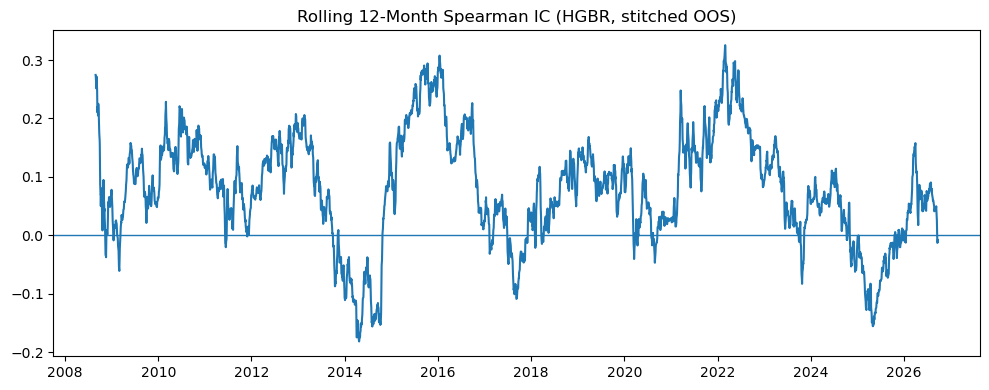


Regime-conditional IC (HGBR, stitched OOS):
            regime  bucket    n  spearman_ic  mean_y  mean_pred
regime_high_growth     0.0 4519       0.0607  0.0024    -0.0086
regime_high_growth     1.0  143       0.0149  0.0063    -0.0034
  regime_high_infl     0.0 3339       0.0588  0.0022    -0.0072
  regime_high_infl     1.0 1323       0.0856  0.0036    -0.0117
   regime_high_vol     0.0 2648       0.0628  0.0027    -0.0090
   regime_high_vol     1.0 2014       0.0606  0.0024    -0.0078

IC by SPY_vol20 quartile (0=lowest vol -> 3=highest vol):
            regime  bucket    n  spearman_ic  mean_vol  mean_y
SPY_vol20_quartile       0 1133       0.0339    0.0048  0.0010
SPY_vol20_quartile       1 1133       0.0547    0.0071  0.0028
SPY_vol20_quartile       2 1132       0.0705    0.0099  0.0024
SPY_vol20_quartile       3 1133       0.0837    0.0192  0.0037


In [10]:
# ============================================================
# Rolling 12-month IC + Regime-Conditional IC (OOS predictions)
# Uses your stitched OOS predictions already computed: oos_preds["HGBR"] and y
# Also uses df_feat (features + regimes) aligned on the same date index
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- helpers ----------
def spearman_ic(a, b):
    a = pd.Series(a).rank(pct=True)
    b = pd.Series(b).rank(pct=True)
    return float(a.corr(b))

def rolling_ic(y_true: pd.Series, y_pred: pd.Series, window_days=252, min_obs=126):
    """Rolling Spearman IC on daily index, using approx trading-day window (252)."""
    s = pd.concat([y_true.rename("y"), y_pred.rename("p")], axis=1).dropna()
    out = pd.Series(index=s.index, dtype=float, name="rolling_ic")

    for i in range(len(s)):
        end = s.index[i]
        start_loc = max(0, i - window_days + 1)
        w = s.iloc[start_loc:i+1]
        if len(w) >= min_obs and w["y"].nunique() > 1 and w["p"].nunique() > 1:
            out.iloc[i] = spearman_ic(w["y"], w["p"])
        else:
            out.iloc[i] = np.nan
    return out

def summarize_regime_ic(y_true, y_pred, regime: pd.Series, name="regime"):
    """Compute IC and n for each regime bucket (0/1)."""
    s = pd.concat([y_true.rename("y"), y_pred.rename("p"), regime.rename("r")], axis=1).dropna()
    rows = []
    for val in sorted(s["r"].dropna().unique()):
        sub = s[s["r"] == val]
        ic = spearman_ic(sub["y"], sub["p"]) if len(sub) >= 50 else np.nan
        rows.append({"regime": name, "bucket": val, "n": len(sub), "spearman_ic": ic,
                     "mean_y": float(sub["y"].mean()), "mean_pred": float(sub["p"].mean())})
    return pd.DataFrame(rows)

# ---------- prerequisites ----------
assert "oos_preds" in globals(), "Run the regression cell first so oos_preds exists."
assert "y" in globals(), "Run the regression cell first so y (y_ret_next5d) exists."
assert "df_feat" in globals(), "Run the regression cell first so df_feat (with regime columns) exists."
assert "HGBR" in oos_preds, "Need oos_preds['HGBR'] from the regression cell."

# Use HGBR stitched OOS predictions
p = oos_preds["HGBR"].dropna()
yy = y.loc[p.index]

# ---------- 1) Rolling 12-month IC ----------
# Use 252 trading days as ~12 months
ric = rolling_ic(yy, p, window_days=252, min_obs=126)

print("Rolling IC summary (non-NaN):")
print(ric.dropna().describe().round(4))

plt.figure(figsize=(10,4))
plt.plot(ric.index, ric.values)
plt.axhline(0, linewidth=1)
plt.title("Rolling 12-Month Spearman IC (HGBR, stitched OOS)")
plt.tight_layout()
plt.show()

# ---------- 2) Regime-conditional IC ----------
# We’ll use regime flags from df_feat; align to prediction dates.
# If any are missing, the code will skip them.
regime_cols = [
    "regime_high_vol",
    "regime_high_infl",
    "regime_high_growth"
]

regime_tables = []
for col in regime_cols:
    if col in df_feat.columns:
        r = df_feat[col].loc[p.index]
        regime_tables.append(summarize_regime_ic(yy, p, r, name=col))
    else:
        print(f"[INFO] Regime column not found, skipping: {col}")

if regime_tables:
    reg_ic = pd.concat(regime_tables, axis=0, ignore_index=True)
    print("\nRegime-conditional IC (HGBR, stitched OOS):")
    print(reg_ic.sort_values(["regime","bucket"]).round(4).to_string(index=False))

# ---------- 3) Optional: IC by Volatility Quartiles (richer than binary) ----------
if "SPY_vol20" in df_feat.columns:
    vol = df_feat["SPY_vol20"].loc[p.index]
    s = pd.concat([yy.rename("y"), p.rename("p"), vol.rename("vol")], axis=1).dropna()
    s["vol_q"] = pd.qcut(s["vol"], 4, labels=False, duplicates="drop")

    rows = []
    for q in sorted(s["vol_q"].unique()):
        sub = s[s["vol_q"] == q]
        rows.append({"regime": "SPY_vol20_quartile", "bucket": int(q), "n": len(sub),
                     "spearman_ic": spearman_ic(sub["y"], sub["p"]),
                     "mean_vol": float(sub["vol"].mean()),
                     "mean_y": float(sub["y"].mean())})
    vol_q_ic = pd.DataFrame(rows)
    print("\nIC by SPY_vol20 quartile (0=lowest vol -> 3=highest vol):")
    print(vol_q_ic.round(4).to_string(index=False))
else:
    print("[INFO] SPY_vol20 not found; skipping volatility quartile IC.")


Correct Stitched OOS IC (HGBR): 0.060522

Features with valid importance estimates: 68 / 68

Top 20 TRUE OOS IC Drivers (full precision):
FVX                  0.0216126951
SPY_mom20            0.0160641862
VIX9D                0.0133260247
SPY_dd20             0.0121069719
CL                   0.0107279875
TNX_ret10            0.0099391181
ES_ret5              0.0098345702
GC_ret10             0.0059480962
CL_ret5              0.0058177478
NQ_ret10             0.0048712819
Yield_slope_5y_3m    0.0045250419
TNX_ret5             0.0043365178
VIX9D_ret5           0.0042978188
TNX                  0.0041426431
SPY                  0.0036980630
IRX_ret5             0.0035542824
SPY_ret10            0.0024725565
CL_ret10             0.0024498577
NQ_ret5              0.0023680749
VIX_ret1             0.0022706195
dtype: object


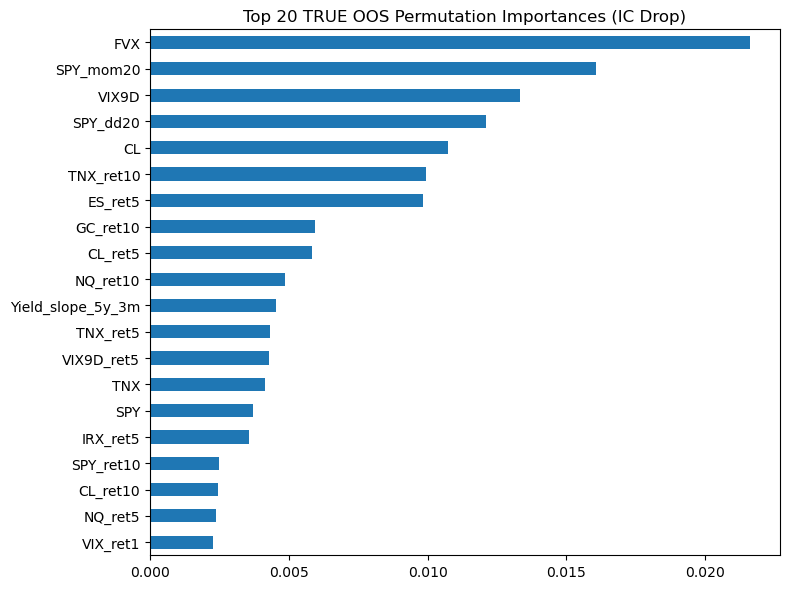


Bottom 10 (most negative / least helpful):
ES                    -0.0020439284
Yield_slope_10y_3m    -0.0021216075
SPY_vol20             -0.0021343768
DXY_ret5              -0.0021642320
SPY_ret1              -0.0024737823
FVX_ret10             -0.0031995303
DJI_ret10             -0.0041051262
IRX                   -0.0050982329
SPY_vol10             -0.0065520164
CPI_yoy               -0.0101902496
dtype: object


In [11]:
# ============================================================
# TRUE OOS Permutation Importance (Fold-by-Fold, No Refit)
#   - Proper estimator cloning (no state leakage across folds)
#   - Robust Spearman IC (handles constant vectors)
#   - Permute only observed values (keeps NaNs fixed)
#   - Fold-safe feature alignment (drop train-all-NaN cols, keep Xte aligned)
#   - Iterate over fold columns (prevents KeyError like 'VIX9D')
#   - Keeps full precision (small IC drops don't look like zeros)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

# -----------------------------
# Robust Spearman IC (no scipy)
# -----------------------------
def spearman_ic(y_true, y_pred) -> float:
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred)

    # If either is constant, correlation is undefined -> return NaN
    if y_true.nunique(dropna=True) < 2 or y_pred.nunique(dropna=True) < 2:
        return np.nan

    rt = y_true.rank(pct=True)
    rp = y_pred.rank(pct=True)
    return float(rt.corr(rp))

# -----------------------------
# Permute only observed values (keep NaNs fixed)
# -----------------------------
def permute_observed(col: pd.Series, rng: np.random.Generator) -> pd.Series:
    s = col.copy()
    mask = s.notna().values
    vals = s.values.copy()
    vals_obs = vals[mask]
    if len(vals_obs) >= 2:
        vals[mask] = rng.permutation(vals_obs)
    # else leave as-is (too few values to permute)
    return pd.Series(vals, index=s.index)

# -----------------------------
# Fold-safe: drop all-NaN-in-train columns and align Xte
# -----------------------------
def align_drop_all_nan(Xtr: pd.DataFrame, Xte: pd.DataFrame):
    all_nan = Xtr.columns[Xtr.isna().all()].tolist()
    if all_nan:
        Xtr = Xtr.drop(columns=all_nan)
        Xte = Xte.drop(columns=all_nan, errors="ignore")
    # Ensure identical columns/order
    Xte = Xte.reindex(columns=Xtr.columns)
    return Xtr, Xte, all_nan

# -----------------------------
# Preconditions
# -----------------------------
assert "X" in globals(), "X not found. Run your setup cell first."
assert "y" in globals(), "y not found. Run your setup cell first."
assert "models" in globals(), "models dict not found. Run your setup cell first."
assert "HGBR" in models, "models['HGBR'] not found."

# -----------------------------
# 1) Build stitched OOS predictions (fold-by-fold)
# -----------------------------
tscv = TimeSeriesSplit(n_splits=6)
baseline_preds = pd.Series(index=X.index, dtype=float)

for train_idx, test_idx in tscv.split(X):
    Xtr = X.iloc[train_idx].copy()
    Xte = X.iloc[test_idx].copy()
    ytr = y.iloc[train_idx]

    # fold-safe alignment (prevents imputer warnings + col mismatch)
    Xtr, Xte, _ = align_drop_all_nan(Xtr, Xte)

    model = clone(models["HGBR"])     # IMPORTANT: clone per fold
    model.fit(Xtr, ytr)

    baseline_preds.iloc[test_idx] = model.predict(Xte)

baseline_preds = baseline_preds.dropna()
y_oos = y.loc[baseline_preds.index]
X_oos = X.loc[baseline_preds.index]

stitched_oos_ic = spearman_ic(y_oos, baseline_preds)
print(f"Correct Stitched OOS IC (HGBR): {stitched_oos_ic:.6f}")

# -----------------------------
# 2) TRUE OOS permutation importance (IC drop)
#    Permute features inside each test fold and measure IC degradation.
# -----------------------------
ic_drops = {col: [] for col in X.columns}
rng = np.random.default_rng(42)

# Re-init tscv to iterate same splits again
tscv = TimeSeriesSplit(n_splits=6)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    Xtr = X.iloc[train_idx].copy()
    Xte = X.iloc[test_idx].copy()
    ytr = y.iloc[train_idx]
    yte = y.iloc[test_idx]

    # fold-safe alignment (prevents all-NaN cols + ensures Xte columns match)
    Xtr, Xte, _ = align_drop_all_nan(Xtr, Xte)

    model = clone(models["HGBR"])     # IMPORTANT: clone per fold
    model.fit(Xtr, ytr)

    base_pred = pd.Series(model.predict(Xte), index=Xte.index)
    base_ic = spearman_ic(yte, base_pred)

    # If IC is not defined for this fold, skip it
    if np.isnan(base_ic):
        continue

    # IMPORTANT: iterate over fold columns (prevents KeyError for dropped cols)
    for col in Xte.columns:
        X_perm = Xte.copy()
        X_perm[col] = permute_observed(X_perm[col], rng)

        pred_perm = pd.Series(model.predict(X_perm), index=X_perm.index)
        ic_perm = spearman_ic(yte, pred_perm)

        if not np.isnan(ic_perm):
            ic_drops[col].append(base_ic - ic_perm)

# -----------------------------
# 3) Aggregate results
# -----------------------------
avg_ic_drop = pd.Series(
    {col: (np.mean(vals) if len(vals) > 0 else np.nan) for col, vals in ic_drops.items()}
).sort_values(ascending=False)

# Helpful diagnostics
valid_cols = avg_ic_drop.dropna()
print(f"\nFeatures with valid importance estimates: {len(valid_cols)} / {len(avg_ic_drop)}")

print("\nTop 20 TRUE OOS IC Drivers (full precision):")
print(valid_cols.head(20).apply(lambda v: f"{v:.10f}"))

# -----------------------------
# 4) Plot top drivers
# -----------------------------
top20 = valid_cols.head(20)

plt.figure(figsize=(8, 6))
top20.sort_values().plot(kind="barh")
plt.title("Top 20 TRUE OOS Permutation Importances (IC Drop)")
plt.tight_layout()
plt.show()

# -----------------------------
# 5) (Optional) Also show bottom 10 (features that might add noise)
# -----------------------------
print("\nBottom 10 (most negative / least helpful):")
print(valid_cols.tail(10).apply(lambda v: f"{v:.10f}"))


Baseline features: 68
Pruned features:   58
Dropped: ['CPI_yoy', 'TNX_ret1', 'FVX_ret1', 'SPY_vol20', 'IRX_ret10', 'regime_high_infl', 'DXY', 'IRX_ret5', 'DJI_ret10', 'DXY_ret10']
[INFO] Dropped all-NaN-in-train cols in some folds (5): ['VIX9D', 'VIX9D_ret1', 'VIX9D_ret10', 'VIX9D_ret5', 'VIX_term']
[INFO] Dropped all-NaN-in-train cols in some folds (5): ['VIX9D', 'VIX9D_ret1', 'VIX9D_ret10', 'VIX9D_ret5', 'VIX_term']

=== IC Comparison (stitched OOS) ===
Baseline IC: 0.060522
Pruned   IC: 0.062614
Delta (Pruned - Baseline): +0.002093

Fold ICs (Baseline): [0.1093 0.0268 0.1308 0.0757 0.174  0.0041]
Fold ICs (Pruned):   [0.1383 0.0107 0.1033 0.1051 0.139  0.0816]

=== Decile Spread (top-bottom, stitched OOS) ===
Baseline spread: 0.004435
Pruned   spread: 0.005698

=== Overlay Strategy Stats (non-overlapping) ===
Baseline: {'n_trades': 933, 'threshold': 0.0, 'tc_bps': 5.0, 'mean_ret_per_trade': 0.001, 'vol_ret_per_trade': 0.0177, 'approx_sharpe': 0.4201, 'hit_rate': 0.2165, 'total_retur

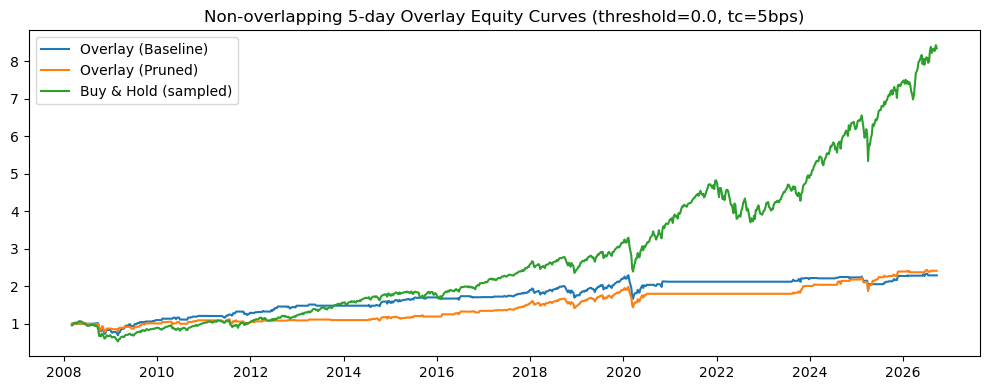


Exposure (% invested):
Baseline: 0.353
Pruned:   0.345


In [12]:
# ============================================================
# 1) Pruned-feature model + IC comparison
# 2) Clean tradable overlay strategy (non-overlapping 5-day holds)
#
# Corrections included:
#   - Fold-safe feature alignment: drop train-all-NaN cols per fold + reindex Xte
#   - Proper estimator cloning (no leakage)
#   - Robust Spearman IC (handles constant vectors)
#   - Decile spread uses qcut safely
#   - Overlay is truly non-overlapping and aligned to stitched OOS preds
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

# -----------------------------
# Robust Spearman IC (no scipy)
# -----------------------------
def spearman_ic(y_true, y_pred) -> float:
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred)
    if y_true.nunique(dropna=True) < 2 or y_pred.nunique(dropna=True) < 2:
        return np.nan
    return float(y_true.rank(pct=True).corr(y_pred.rank(pct=True)))

# -----------------------------
# Fold-safe: drop all-NaN-in-train columns and align Xte
# -----------------------------
def align_drop_all_nan(Xtr: pd.DataFrame, Xte: pd.DataFrame):
    all_nan = Xtr.columns[Xtr.isna().all()].tolist()
    if all_nan:
        Xtr = Xtr.drop(columns=all_nan)
        Xte = Xte.drop(columns=all_nan, errors="ignore")
    Xte = Xte.reindex(columns=Xtr.columns)
    return Xtr, Xte, all_nan

# -----------------------------
# Preconditions
# -----------------------------
assert "X" in globals(), "X not found. Run your setup cell first."
assert "y" in globals(), "y not found. Run your setup cell first."
assert "models" in globals() and "HGBR" in models, "Need models['HGBR'] from your setup."

# -----------------------------
# Your prune list (bottom/negative drivers)
# (Drop these features if present)
# -----------------------------
DROP_FEATURES = [
    "CPI_yoy",
    "TNX_ret1",
    "FVX_ret1",
    "SPY_vol20",
    "IRX_ret10",
    "regime_high_infl",
    "DXY",
    "IRX_ret5",
    "DJI_ret10",
    "DXY_ret10",
]

X_base = X.copy()
X_pruned = X.drop(columns=[c for c in DROP_FEATURES if c in X.columns], errors="ignore").copy()

print(f"Baseline features: {X_base.shape[1]}")
print(f"Pruned features:   {X_pruned.shape[1]}")
print("Dropped:", [c for c in DROP_FEATURES if c in X.columns])

# -----------------------------
# Build stitched OOS preds (baseline vs pruned)
# -----------------------------
def stitched_oos_preds_and_ic(X_in: pd.DataFrame, y_in: pd.Series, base_model, n_splits=6):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    preds = pd.Series(index=X_in.index, dtype=float)

    fold_ics = []
    dropped_any = set()

    for fold, (tr, te) in enumerate(tscv.split(X_in), 1):
        Xtr = X_in.iloc[tr].copy()
        Xte = X_in.iloc[te].copy()
        ytr = y_in.iloc[tr]
        yte = y_in.iloc[te]

        # fold-safe alignment
        Xtr, Xte, dropped = align_drop_all_nan(Xtr, Xte)
        for c in dropped:
            dropped_any.add(c)

        m = clone(base_model)
        m.fit(Xtr, ytr)

        p = pd.Series(m.predict(Xte), index=Xte.index)
        preds.iloc[te] = p.values

        fold_ics.append(spearman_ic(yte, p))

    preds = preds.dropna()
    ic_stitched = spearman_ic(y_in.loc[preds.index], preds)

    if dropped_any:
        print(f"[INFO] Dropped all-NaN-in-train cols in some folds ({len(dropped_any)}): {sorted(dropped_any)[:12]}"
              + (" ..." if len(dropped_any) > 12 else ""))

    return preds, ic_stitched, pd.Series(fold_ics, name="fold_ic")

base_model = models["HGBR"]

pred_base, ic_base, fold_ic_base = stitched_oos_preds_and_ic(X_base, y, base_model, n_splits=6)
pred_prun, ic_prun, fold_ic_prun = stitched_oos_preds_and_ic(X_pruned, y, base_model, n_splits=6)

print("\n=== IC Comparison (stitched OOS) ===")
print(f"Baseline IC: {ic_base:.6f}")
print(f"Pruned   IC: {ic_prun:.6f}")
print(f"Delta (Pruned - Baseline): {ic_prun - ic_base:+.6f}")

print("\nFold ICs (Baseline):", np.round(fold_ic_base.values, 4))
print("Fold ICs (Pruned):  ", np.round(fold_ic_prun.values, 4))

# -----------------------------
# Optional: decile spread check (stitched OOS)
# -----------------------------
def decile_spread(y_true, y_pred, n=10):
    s = pd.DataFrame({"y": y_true, "p": y_pred}).dropna()
    # qcut can fail if too many ties; duplicates="drop" handles it
    s["bucket"] = pd.qcut(s["p"], n, labels=False, duplicates="drop")
    g = s.groupby("bucket")["y"].mean()
    spread = float(g.iloc[-1] - g.iloc[0]) if len(g) >= 2 else np.nan
    return g, spread

yy_base = y.loc[pred_base.index]
yy_prun = y.loc[pred_prun.index]

g_base, spread_base = decile_spread(yy_base, pred_base, n=10)
g_prun, spread_prun = decile_spread(yy_prun, pred_prun, n=10)

print("\n=== Decile Spread (top-bottom, stitched OOS) ===")
print(f"Baseline spread: {spread_base:.6f}")
print(f"Pruned   spread: {spread_prun:.6f}")

# -----------------------------
# TRADABLE OVERLAY STRATEGY (non-overlapping 5-day holds)
# Long SPY if predicted 5d return > threshold, else cash.
# Uses stitched OOS predictions to avoid leakage.
# -----------------------------
def overlay_backtest_nonoverlap(pred: pd.Series,
                                y_true: pd.Series,
                                step=5,
                                threshold=0.0,
                                tc_bps=5):
    """
    Non-overlapping overlay backtest:
      - Decision dates = every 'step' rows (step=5 for 5-day horizon)
      - Position = 1 if pred > threshold else 0
      - Realized holding return = y_true at decision date (which is 5-day forward return)
      - Transaction cost charged when position changes (tc_bps, one-way per change)
    """
    s = pd.DataFrame({"pred": pred, "y": y_true}).dropna().copy()

    # Ensure chronological order
    s = s.sort_index()

    # Take non-overlapping decision points
    decision = s.iloc[::step].copy()

    decision["pos"] = (decision["pred"] > threshold).astype(int)

    # Transaction cost on position change
    tc = tc_bps / 10000.0
    decision["turnover"] = decision["pos"].diff().abs().fillna(decision["pos"].abs())
    decision["cost"] = decision["turnover"] * tc

    # Strategy return over next step days (held position)
    decision["strat_ret"] = decision["pos"] * decision["y"] - decision["cost"]

    # Equity curves (sampled at decision frequency)
    decision["eq_strat"] = (1 + decision["strat_ret"]).cumprod()
    decision["eq_buyhold"] = (1 + decision["y"]).cumprod()

    # Simple stats
    mean = float(decision["strat_ret"].mean())
    vol = float(decision["strat_ret"].std(ddof=0))
    sharpe = (mean / vol * np.sqrt(252/step)) if vol > 0 else np.nan

    total = float(decision["eq_strat"].iloc[-1] - 1.0)
    hit = float((decision["strat_ret"] > 0).mean())

    stats = {
        "n_trades": int(len(decision)),
        "threshold": float(threshold),
        "tc_bps": float(tc_bps),
        "mean_ret_per_trade": mean,
        "vol_ret_per_trade": vol,
        "approx_sharpe": float(sharpe),
        "hit_rate": hit,
        "total_return": total
    }
    return decision, stats

THRESH = 0.0
STEP = 5
TC_BPS = 5

bt_base, stats_base = overlay_backtest_nonoverlap(pred_base, yy_base, step=STEP, threshold=THRESH, tc_bps=TC_BPS)
bt_prun, stats_prun = overlay_backtest_nonoverlap(pred_prun, yy_prun, step=STEP, threshold=THRESH, tc_bps=TC_BPS)

print("\n=== Overlay Strategy Stats (non-overlapping) ===")
print("Baseline:", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in stats_base.items()})
print("Pruned:  ", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in stats_prun.items()})

# Plot equity curves
plt.figure(figsize=(10, 4))
plt.plot(bt_base.index, bt_base["eq_strat"], label="Overlay (Baseline)")
plt.plot(bt_prun.index, bt_prun["eq_strat"], label="Overlay (Pruned)")
plt.plot(bt_base.index, bt_base["eq_buyhold"], label="Buy & Hold (sampled)")
plt.title(f"Non-overlapping {STEP}-day Overlay Equity Curves (threshold={THRESH}, tc={TC_BPS}bps)")
plt.legend()
plt.tight_layout()
plt.show()

print("\nExposure (% invested):")
print(f"Baseline: {bt_base['pos'].mean():.3f}")
print(f"Pruned:   {bt_prun['pos'].mean():.3f}")


=== Overlay Threshold Sweep (sorted by Sharpe) ===
   model rule  threshold  approx_sharpe  total_return  buyhold_return  exposure  n_trades  mean_ret_per_trade  vol_ret_per_trade
Baseline  q50    -0.0042         0.6414        3.2712          7.3374    0.5016       933              0.0017             0.0193
Baseline  q55    -0.0026         0.6196        2.9427          7.3374    0.4598       933              0.0017             0.0190
Baseline mean    -0.0085         0.5946        3.0515          7.3374    0.6195       933              0.0017             0.0205
Baseline  q60    -0.0012         0.5400        2.1145          7.3374    0.4094       933              0.0014             0.0183
Baseline  q70     0.0014         0.4780        1.5514          7.3374    0.3055       933              0.0012             0.0172
Baseline  q75     0.0029         0.4459        1.3062          7.3374    0.2476       933              0.0010             0.0165
Baseline  q80     0.0047         0.4264       

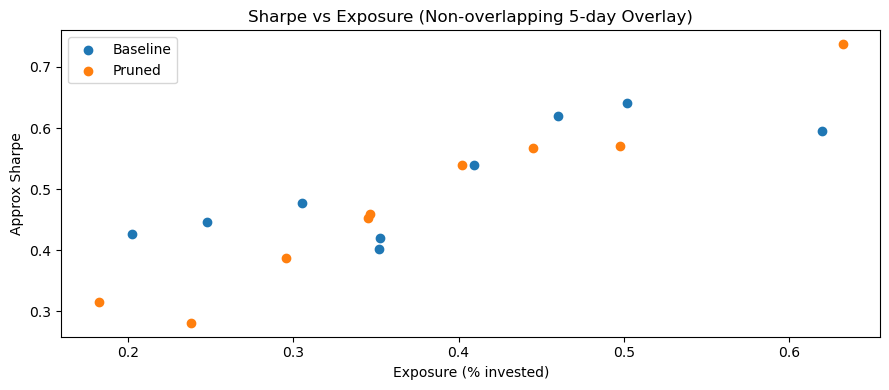


=== Best Rule per Model ===
Baseline best: rule=q50, thr=-0.004162, sharpe=0.641, exposure=0.502, total=327.12%
Pruned   best: rule=mean, thr=-0.010215, sharpe=0.737, exposure=0.632, total=491.71%


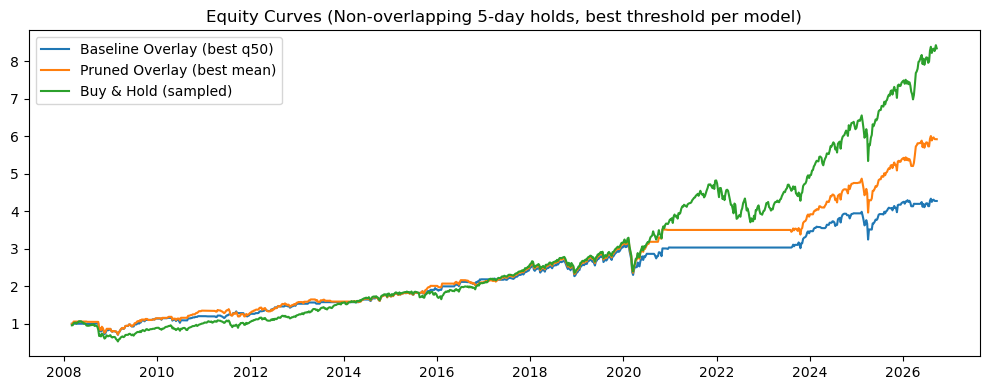

In [13]:
# ============================================================
# Threshold Sweep for Long-Only Overlay (Non-overlapping 5-day holds)
#   - Tests multiple threshold rules for Baseline vs Pruned models
#   - Reports Sharpe, total return, exposure, etc.
#   - Plots Sharpe vs Exposure + Equity curves for best threshold
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Preconditions
# -----------------------------
# Requires these from your prior cells:
#   pred_base (stitched OOS preds for baseline)
#   pred_prun (stitched OOS preds for pruned)
#   yy_base   (y aligned to pred_base)
#   yy_prun   (y aligned to pred_prun)
assert "pred_base" in globals(), "pred_base not found. Run the pruned-vs-baseline cell first."
assert "pred_prun" in globals(), "pred_prun not found. Run the pruned-vs-baseline cell first."
assert "yy_base" in globals(), "yy_base not found. Run the pruned-vs-baseline cell first."
assert "yy_prun" in globals(), "yy_prun not found. Run the pruned-vs-baseline cell first."

# -----------------------------
# Overlay backtest (non-overlapping)
# -----------------------------
def overlay_backtest_nonoverlap(pred: pd.Series,
                                y_true: pd.Series,
                                step=5,
                                threshold=0.0,
                                tc_bps=5):
    s = pd.DataFrame({"pred": pred, "y": y_true}).dropna().copy()
    decision = s.iloc[::step].copy()

    decision["pos"] = (decision["pred"] > threshold).astype(int)

    tc = tc_bps / 10000.0
    decision["turnover"] = decision["pos"].diff().abs().fillna(decision["pos"].abs())
    decision["cost"] = decision["turnover"] * tc

    decision["strat_ret"] = decision["pos"] * decision["y"] - decision["cost"]

    decision["eq_strat"] = (1 + decision["strat_ret"]).cumprod()
    decision["eq_buyhold"] = (1 + decision["y"]).cumprod()

    mean = float(decision["strat_ret"].mean())
    vol = float(decision["strat_ret"].std(ddof=0))
    sharpe = (mean / vol * np.sqrt(252/step)) if vol > 0 else np.nan

    stats = {
        "n_trades": int(len(decision)),
        "threshold": float(threshold),
        "tc_bps": float(tc_bps),
        "step": int(step),
        "exposure": float(decision["pos"].mean()),
        "mean_ret_per_trade": mean,
        "vol_ret_per_trade": vol,
        "approx_sharpe": float(sharpe),
        "total_return": float(decision["eq_strat"].iloc[-1] - 1.0),
        "buyhold_return": float(decision["eq_buyhold"].iloc[-1] - 1.0),
    }
    return decision, stats

# -----------------------------
# Build threshold grid
# -----------------------------
STEP = 5
TC_BPS = 5

# Quantile thresholds are computed from the prediction distribution (OOS)
def threshold_grid(pred: pd.Series):
    qs = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
    q_vals = {f"q{int(q*100)}": float(pred.quantile(q)) for q in qs}
    grid = {
        "zero": 0.0,
        "mean": float(pred.mean()),
        **q_vals
    }
    return grid

grid_base = threshold_grid(pred_base)
grid_prun = threshold_grid(pred_prun)

# -----------------------------
# Run sweep
# -----------------------------
rows = []

def run_sweep(name, pred, yy, grid):
    for label, thr in grid.items():
        bt, st = overlay_backtest_nonoverlap(pred, yy, step=STEP, threshold=thr, tc_bps=TC_BPS)
        rows.append({
            "model": name,
            "rule": label,
            **st
        })

run_sweep("Baseline", pred_base, yy_base, grid_base)
run_sweep("Pruned", pred_prun, yy_prun, grid_prun)

res = pd.DataFrame(rows)

# Sort by Sharpe within each model
res_sorted = res.sort_values(["model", "approx_sharpe"], ascending=[True, False])

print("=== Overlay Threshold Sweep (sorted by Sharpe) ===")
display_cols = ["model","rule","threshold","approx_sharpe","total_return","buyhold_return","exposure","n_trades","mean_ret_per_trade","vol_ret_per_trade"]
print(res_sorted[display_cols].round(4).to_string(index=False))

# -----------------------------
# Plot: Sharpe vs Exposure
# -----------------------------
plt.figure(figsize=(9,4))
for m in ["Baseline","Pruned"]:
    sub = res[res["model"] == m].copy()
    plt.scatter(sub["exposure"], sub["approx_sharpe"], label=m)

plt.xlabel("Exposure (% invested)")
plt.ylabel("Approx Sharpe")
plt.title("Sharpe vs Exposure (Non-overlapping 5-day Overlay)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Pick best threshold per model and plot equity curves
# -----------------------------
best_base = res[res["model"]=="Baseline"].sort_values("approx_sharpe", ascending=False).iloc[0]
best_prun = res[res["model"]=="Pruned"].sort_values("approx_sharpe", ascending=False).iloc[0]

bt_base, _ = overlay_backtest_nonoverlap(pred_base, yy_base, step=STEP, threshold=float(best_base["threshold"]), tc_bps=TC_BPS)
bt_prun, _ = overlay_backtest_nonoverlap(pred_prun, yy_prun, step=STEP, threshold=float(best_prun["threshold"]), tc_bps=TC_BPS)

print("\n=== Best Rule per Model ===")
print(f"Baseline best: rule={best_base['rule']}, thr={best_base['threshold']:.6f}, sharpe={best_base['approx_sharpe']:.3f}, exposure={best_base['exposure']:.3f}, total={best_base['total_return']:.2%}")
print(f"Pruned   best: rule={best_prun['rule']}, thr={best_prun['threshold']:.6f}, sharpe={best_prun['approx_sharpe']:.3f}, exposure={best_prun['exposure']:.3f}, total={best_prun['total_return']:.2%}")

plt.figure(figsize=(10,4))
plt.plot(bt_base.index, bt_base["eq_strat"], label=f"Baseline Overlay (best {best_base['rule']})")
plt.plot(bt_prun.index, bt_prun["eq_strat"], label=f"Pruned Overlay (best {best_prun['rule']})")
plt.plot(bt_prun.index, bt_prun["eq_buyhold"], label="Buy & Hold (sampled)")
plt.title("Equity Curves (Non-overlapping 5-day holds, best threshold per model)")
plt.legend()
plt.tight_layout()
plt.show()


=== Volatility Targeted Overlay Stats ===
Sharpe: 0.8469
Mean_Return_per_trade: 0.0021
Vol_per_trade: 0.0180
Total_Return: 5.1057
BuyHold_Return: 7.3374
Avg_Exposure: 0.7584


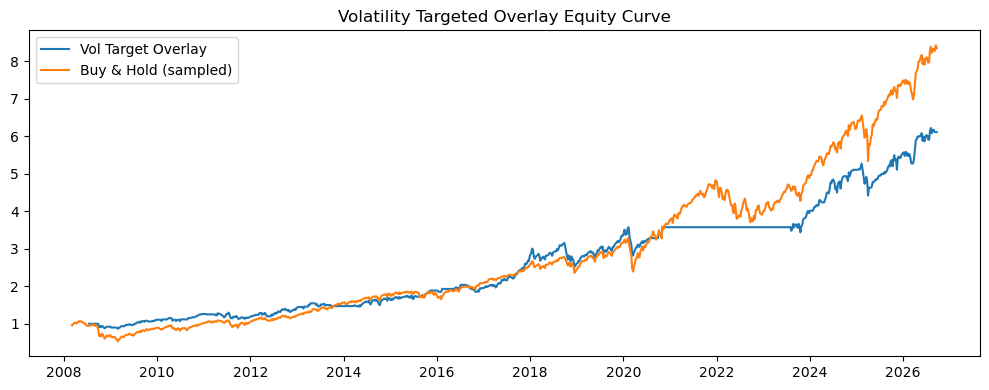

In [14]:
# ============================================================
# Volatility Targeted Overlay (Non-overlapping 5-day)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use pruned stitched OOS predictions
pred = pred_prun.copy()
yy = yy_prun.copy()

STEP = 5
TC_BPS = 5
TARGET_VOL_ANNUAL = 0.15   # 15% annual target volatility

def vol_target_overlay(pred, y_true, step=5, tc_bps=5, target_vol_annual=0.15):

    s = pd.DataFrame({"pred": pred, "y": y_true}).dropna().copy()
    decision = s.iloc[::step].copy()

    # Signal rule: mean threshold
    threshold = float(pred.mean())
    decision["signal"] = (decision["pred"] > threshold).astype(int)

    # Estimate rolling realized volatility (20-period window)
    rolling_vol = decision["y"].rolling(20).std(ddof=0)

    # Convert annual vol to per-5day vol
    target_vol_per_period = target_vol_annual / np.sqrt(252/step)

    # Position sizing
    decision["pos"] = decision["signal"] * (
        target_vol_per_period / rolling_vol
    )

    # Cap leverage to avoid blowups
    decision["pos"] = decision["pos"].clip(upper=2.0)

    # Transaction cost on exposure change
    tc = tc_bps / 10000.0
    decision["turnover"] = decision["pos"].diff().abs().fillna(decision["pos"].abs())
    decision["cost"] = decision["turnover"] * tc

    decision["strat_ret"] = decision["pos"] * decision["y"] - decision["cost"]

    decision["eq"] = (1 + decision["strat_ret"]).cumprod()
    decision["eq_buyhold"] = (1 + decision["y"]).cumprod()

    mean = decision["strat_ret"].mean()
    vol = decision["strat_ret"].std(ddof=0)
    sharpe = mean / vol * np.sqrt(252/step)

    stats = {
        "Sharpe": float(sharpe),
        "Mean_Return_per_trade": float(mean),
        "Vol_per_trade": float(vol),
        "Total_Return": float(decision["eq"].iloc[-1] - 1),
        "BuyHold_Return": float(decision["eq_buyhold"].iloc[-1] - 1),
        "Avg_Exposure": float(decision["pos"].mean())
    }

    return decision, stats

bt_vol, stats_vol = vol_target_overlay(pred, yy, step=STEP,
                                       tc_bps=TC_BPS,
                                       target_vol_annual=TARGET_VOL_ANNUAL)

print("=== Volatility Targeted Overlay Stats ===")
for k, v in stats_vol.items():
    print(f"{k}: {v:.4f}")

plt.figure(figsize=(10,4))
plt.plot(bt_vol.index, bt_vol["eq"], label="Vol Target Overlay")
plt.plot(bt_vol.index, bt_vol["eq_buyhold"], label="Buy & Hold (sampled)")
plt.title("Volatility Targeted Overlay Equity Curve")
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
# ============================================================
# Expanding Window Retrain (Production-Style) — corrected
#   - Fold-safe feature alignment (drop train-all-NaN cols each retrain)
#   - Keeps X_test aligned to X_train columns
#   - Uses STEP-sized prediction blocks (non-overlapping)
#   - Uses your existing spearman_ic()
# ============================================================

from sklearn.base import clone
import numpy as np
import pandas as pd

MIN_TRAIN = 756   # ~3 years of daily data
STEP = 5

pred_expanding = pd.Series(index=X_pruned.index, dtype=float)

# (Assumes align_drop_all_nan() + spearman_ic() already defined above)
for start in range(MIN_TRAIN, len(X_pruned) - STEP + 1, STEP):

    X_train = X_pruned.iloc[:start].copy()
    y_train = y.iloc[:start]

    X_test  = X_pruned.iloc[start:start+STEP].copy()

    # --- fold-safe alignment (prevents imputer warnings / col mismatch) ---
    X_train2, X_test2, dropped = align_drop_all_nan(X_train, X_test)
    # Optional diagnostic:
    # if dropped: print(f"[INFO] start={start}: dropped all-NaN train cols: {dropped}")

    model = clone(models["HGBR"])
    model.fit(X_train2, y_train)

    pred_expanding.iloc[start:start+STEP] = model.predict(X_test2)

pred_expanding = pred_expanding.dropna()
y_exp = y.loc[pred_expanding.index]

ic_expanding = spearman_ic(y_exp, pred_expanding)
print(f"\nExpanding Window OOS IC: {ic_expanding:.6f}")



Expanding Window OOS IC: 0.089344


In [16]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import warnings
warnings.filterwarnings('ignore')


In [17]:
%%time

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["KMP_AFFINITY"] = "noverbose"

tf.get_logger().setLevel('ERROR')

# Reproducibility: fix TensorFlow / NumPy random state
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================
# LSTM Expanding-Window (STEP=5) — NO tf.data, NO retracing spam
# Drop-in cell: builds sequences, scales train-only, trains via train_on_batch
# Requires: X (or X_pruned) as DataFrame, y as Series (same date index)
# ============================================================

# ---------- 1) Spearman IC ----------
def spearman_ic(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    mask = y_true.notna() & y_pred.notna()
    if mask.sum() < 3:
        return np.nan
    return spearmanr(y_true[mask], y_pred[mask]).correlation

# ---------- 2) Sequence builder ----------
def make_lstm_sequences(X_df, y_s, lookback=20):
    """
    Aligns X and y on index, drops NA, then creates rolling lookback windows.
    Returns:
      X_seq: (N, lookback, F) float32
      y_seq: (N,) float32
      idx_seq: date index for each label/pred
    """
    Z = X_df.join(y_s.rename("y"), how="inner").dropna()
    Xv = Z.drop(columns=["y"]).values.astype(np.float32)
    yv = Z["y"].values.astype(np.float32)
    idx = Z.index

    N = len(Z) - lookback + 1
    if N <= 0:
        raise ValueError(f"Not enough rows ({len(Z)}) for lookback={lookback}.")

    X_seq = np.zeros((N, lookback, Xv.shape[1]), dtype=np.float32)
    y_seq = np.zeros((N,), dtype=np.float32)
    idx_seq = []

    for i in range(N):
        X_seq[i] = Xv[i:i+lookback]
        y_seq[i] = yv[i+lookback-1]
        idx_seq.append(idx[i+lookback-1])

    return X_seq, y_seq, pd.Index(idx_seq)

# ---------- 3) Model builder ----------
def build_lstm_model(n_features, lookback, lr=1e-3, units=32, dropout=0.2):
    from tensorflow.keras import layers, models, optimizers
    model = models.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.LSTM(units, dropout=dropout, recurrent_dropout=0.0),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
    return model

# ---------- 4) NO tf.data training + direct predict ----------
def fit_lstm_no_tfdata(model, X_train, y_train, epochs=10, batch_size=32, shuffle=True, seed=42):
    rng = np.random.default_rng(seed)
    N = len(X_train)
    for ep in range(epochs):
        idx = np.arange(N)
        if shuffle:
            rng.shuffle(idx)
        for i in range(0, N, batch_size):
            b = idx[i:i+batch_size]
            model.train_on_batch(X_train[b], y_train[b])

def predict_lstm_direct(model, X_test):
    return model(X_test, training=False).numpy().ravel()

# ---------- 5) Expanding-window OOS ----------
def lstm_expanding_oos_no_tfdata(
    X_df, y_s,
    lookback=20,
    min_train=756,
    step=5,
    epochs=20,
    batch_size=32,
    lr=1e-3,
    units=32,
    dropout=0.2,
    seed=42
):
    X_seq, y_seq, idx_seq = make_lstm_sequences(X_df, y_s, lookback=lookback)
    n_features = X_seq.shape[2]

    pred = pd.Series(index=idx_seq, dtype=float)

    # Convert original-row min_train into sequence-row min_train
    min_train_seq = max(50, min_train - (lookback - 1))

    for train_end in range(min_train_seq, len(idx_seq) - step, step):

        if (train_end - min_train_seq) % (step*10) == 0:
            pct = 100 * (train_end - min_train_seq) / (len(idx_seq) - step - min_train_seq)
            print(f"Walk-forward progress: {pct:.1f}%  (train_end={train_end})")
            
        X_train = X_seq[:train_end]
        y_train = y_seq[:train_end]
        X_test  = X_seq[train_end:train_end+step]

        # ---- scale TRAIN only (fit on flattened time dimension) ----
        scaler = StandardScaler()
        scaler.fit(X_train.reshape(-1, n_features))

        X_train_sc = scaler.transform(X_train.reshape(-1, n_features)).reshape(X_train.shape).astype(np.float32)
        X_test_sc  = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape).astype(np.float32)

        # ---- build + train ----
        model = build_lstm_model(n_features, lookback, lr=lr, units=units, dropout=dropout)

        fit_lstm_no_tfdata(
            model,
            X_train_sc,
            y_train.astype(np.float32),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=True,
            seed=seed
        )

        # ---- predict stitched ----
        p = predict_lstm_direct(model, X_test_sc)
        pred.iloc[train_end:train_end+step] = p

        tf.keras.backend.clear_session()

    pred = pred.dropna()
    y_true = pd.Series(y_seq, index=idx_seq).loc[pred.index]
    return pred, y_true

# ============================================================
# RUN
# ============================================================

# Use pruned features if you have them:
# X_use = X_pruned.copy()
X_use = X.copy()

pred_lstm, y_lstm = lstm_expanding_oos_no_tfdata(
    X_use, y,
    lookback=20,
    min_train=756,
    step=5,
    epochs=25,
    batch_size=32,
    lr=1e-3,
    units=32,
    dropout=0.2,
    seed=42
)

print(f"LSTM Expanding OOS IC: {spearman_ic(y_lstm, pred_lstm):.6f}")

pred_lstm.head()


Walk-forward progress lines trimmed for readability.
LSTM Expanding OOS IC: 0.057381
CPU times: total: 1h 59min 29s
Wall time: 1h 17min 12s


2014-01-21    0.013262
2014-01-22    0.003514
2014-01-23    0.007419
2014-01-24    0.025640
2014-01-27   -0.011554
dtype: float64